In [1]:
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)
path = kagglehub.dataset_download(
    "bhavikjikadara/dog-and-cat-classification-dataset"
)

print(path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
/kaggle/input/dog-and-cat-classification-dataset


In [2]:
for root, dirs, files in os.walk(path):

    print(root)

    break

print()

for folder in os.listdir(path):

    print(folder)
for root, dirs, files in os.walk(path):

    if len(files)>0:

        print(root)

        break

/kaggle/input/dog-and-cat-classification-dataset

PetImages
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog


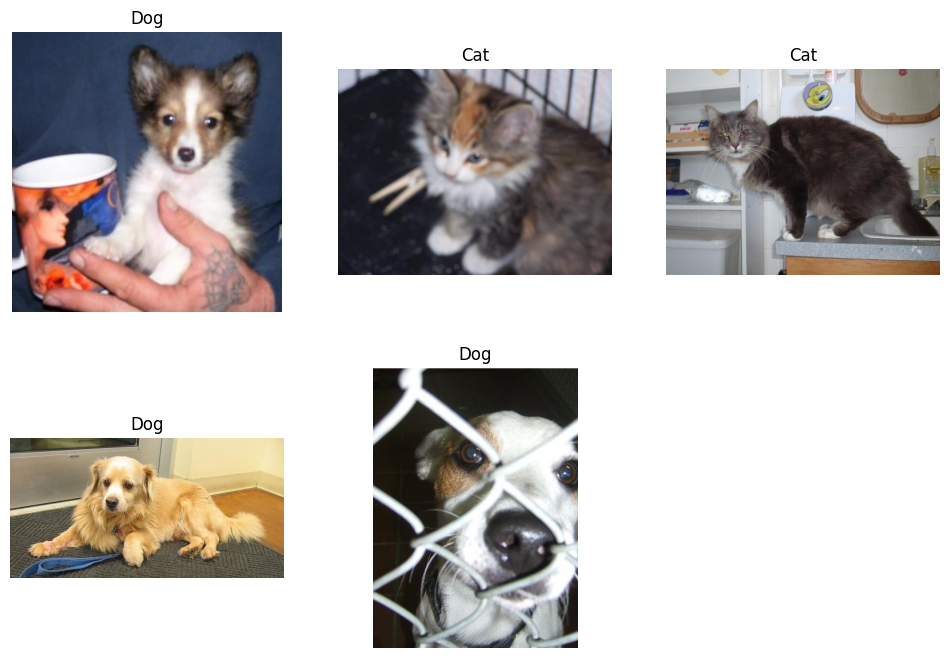

In [5]:
import random
import matplotlib.pyplot as plt
import os

# Correctly identify the base directory containing 'Cat' and 'Dog' folders
base_image_dir = os.path.join(path, 'PetImages')
# Get the class labels (e.g., 'Cat', 'Dog')
classes = os.listdir(base_image_dir)

plt.figure(figsize=(12,8))

for i in range(5):
    label = random.choice(classes) # 'label' will now be 'Cat' or 'Dog'

    # Construct the path to the current class directory
    category_path = os.path.join(base_image_dir, label)

    # List all files in the chosen category directory and filter out subdirectories
    images_in_category = os.listdir(category_path)
    image_files = [f for f in images_in_category if os.path.isfile(os.path.join(category_path, f))]

    if not image_files:
        print(f"No image files found in {category_path}. Skipping.")
        continue

    # Randomly choose an actual image file
    img = random.choice(image_files)

    # Construct the full path to the image file
    image_full_path = os.path.join(category_path, img)

    image = plt.imread(image_full_path)

    plt.subplot(2,3,i+1)

    plt.imshow(image)

    plt.title(label)

    plt.axis("off")

plt.show()

In [6]:
print("Classes :",classes)

print("Number of Classes :",len(classes))

Classes : ['Dog', 'Cat']
Number of Classes : 2


In [11]:
sample = plt.imread(

  os.path.join(

    base_image_dir,

        classes[0],

        os.listdir(

            os.path.join(base_image_dir,classes[0])

        )[0]

    )

)

print(sample.shape)

(375, 500, 3)


In [13]:
total=0

for folder in classes:

    # It's good practice to ensure the path exists and it's a directory
    folder_path = os.path.join(base_image_dir, folder)
    if os.path.isdir(folder_path):
        # Filter out directories and only count files
        image_files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
        total += len(image_files)
    else:
        print(f"Warning: {folder_path} is not a valid directory.")

print("Total Images :",total)

Total Images : 24998


In [15]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2

)

In [16]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2

)

In [18]:
validation_generator = train_datagen.flow_from_directory(

    base_image_dir,

    target_size=(128,128),

    batch_size=32,

    class_mode="binary",

    subset="validation"

)

Found 4998 images belonging to 2 classes.


In [19]:
model = Sequential()

In [20]:
model.add(

    Conv2D(

        32,

        (3,3),

        activation="relu",

        input_shape=(128,128,3)

    )

)

model.add(

    MaxPooling2D(

        pool_size=(2,2)

    )

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.add(

    Conv2D(

        64,

        (3,3),

        activation="relu"

    )

)

model.add(

    MaxPooling2D(

        (2,2)

    )

)

In [22]:
model.add(

    Conv2D(

        128,

        (3,3),

        activation="relu"

    )

)

model.add(

    MaxPooling2D(

        (2,2)

    )

)

In [23]:
model.add(Flatten())

model.add(

    Dense(

        128,

        activation="relu"

    )

)

model.add(

    Dense(

        1,

        activation="sigmoid"

    )

)

In [24]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Create the training generator
train_generator = train_datagen.flow_from_directory(
    base_image_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

# Train the model with reduced epochs and steps to finish within ~1 minute
history = model.fit(
    train_generator,
    steps_per_epoch=50, # Only look at 50 batches per epoch
    validation_data=validation_generator,
    validation_steps=20,
    epochs=1
)

Found 20000 images belonging to 2 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.5794 - loss: 0.6803 - val_accuracy: 0.5781 - val_loss: 0.6732


In [29]:
loss, accuracy = model.evaluate(validation_generator)

print("Test Accuracy :", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 55s 348ms/step - accuracy: 0.5556 - loss: 0.6913
Test Accuracy : 0.5556222200393677


In [30]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

# Reset generator
validation_generator.reset()

# Predict probabilities
predictions = model.predict(validation_generator)

# Convert probabilities to binary labels
y_pred = (predictions > 0.5).astype(int).flatten()

# True labels
y_true = validation_generator.classes

157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 318ms/step


In [31]:
from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_true, y_pred))

Accuracy : 0.49839935974389754


In [32]:
print("Precision :", precision_score(y_true, y_pred))

Precision : 0.4990467111534795


In [33]:
print("F1 Score :", f1_score(y_true, y_pred))
print("Recall :", recall_score(y_true, y_pred))

F1 Score : 0.6255414488424197
Recall : 0.8379351740696278


In [34]:
print(classification_report(
    y_true,
    y_pred,
    target_names=validation_generator.class_indices.keys()
))

              precision    recall  f1-score   support

         Cat       0.50      0.16      0.24      2499
         Dog       0.50      0.84      0.63      2499

    accuracy                           0.50      4998
   macro avg       0.50      0.50      0.43      4998
weighted avg       0.50      0.50      0.43      4998



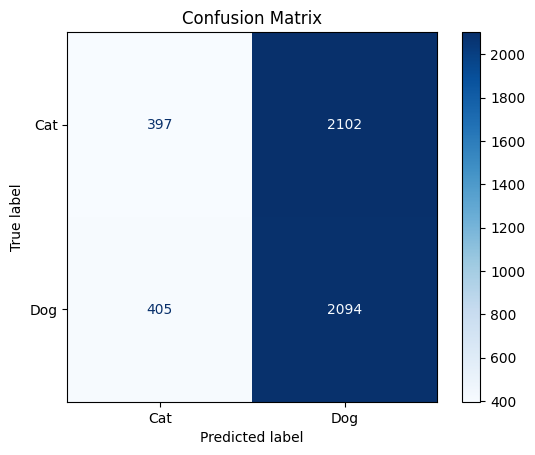

In [36]:
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=validation_generator.class_indices.keys()
).plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()

plt.grid(True)

plt.show()

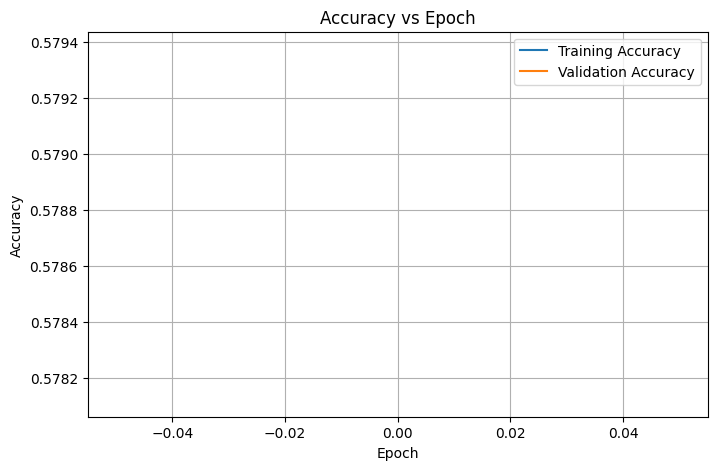

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()

plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


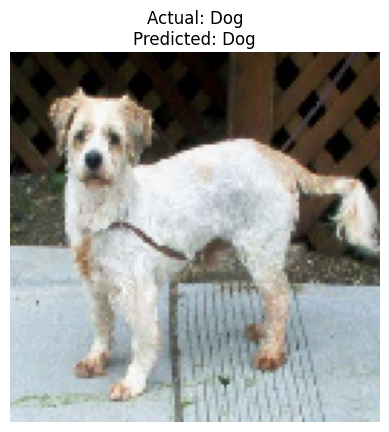

In [39]:
import random
from tensorflow.keras.preprocessing import image
import os
import numpy as np
import matplotlib.pyplot as plt

class_names = list(validation_generator.class_indices.keys())

folder = random.choice(class_names)

img_name = random.choice(
    os.listdir(
        os.path.join(base_image_dir, folder)
    )
)

img_path = os.path.join(
    base_image_dir,
    folder,
    img_name
)

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array /= 255.0

prediction = model.predict(img_array)

predicted_class = class_names[int(prediction[0][0] > 0.5)]

plt.imshow(img)

plt.title(f"Actual: {folder}\nPredicted: {predicted_class}")

plt.axis("off")

plt.show()